In [1]:
from test_func import analize, carregar_anotacoes_em_dict

c:\Users\User\Documents\Alan\microsoft_prisidio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def converter_tipo_entidade(dados):
    """
    Converte os nomes das entidades específicas para tipos genéricos:
    - PES_* → PESSOA
    - END_* → ENDERECO
    - Outros → OUTRO

    Args:
        dados (dict): Dicionário no formato {id: [ {entidade, inicio, fim, texto}, ... ] }

    Returns:
        dict: Mesmo dicionário, mas com chave 'tipo' adicionada em cada entidade.
    """
    resultado_convertido = {}

    for id_doc, entidades in dados.items():
        novas_entidades = []
        for ent in entidades:
            tipo = (
                "PESSOA" if ent["entidade"].startswith("PES") else
                "ENDERECO" if ent["entidade"].startswith("END") else
                "OUTRO"
            )
            nova_entidade = {
                **ent,
                "tipo": tipo
            }
            novas_entidades.append(nova_entidade)

        resultado_convertido[id_doc] = novas_entidades

    return resultado_convertido


In [3]:
cdjur_result = carregar_anotacoes_em_dict('./docs_teste(real)/cdjur-geral/cdjur_geral_140922.json')

In [4]:
anotacoes = converter_tipo_entidade(cdjur_result)

In [ ]:
anotacoes

In [ ]:
analize('Francisco Alan Rodrigues Mesquita é estudante de ciencia da computação e mora em tianguá')

In [ ]:
import os
import json
from tqdm import tqdm
import random

# Caminho para os arquivos .txt
caminho_pasta = "./docs_teste(real)/cdjur-original/"  

# Dicionário final onde cada chave é o nome do arquivo
resultados = {}
print(len(os.listdir(caminho_pasta)))
caminho_pasta = "./docs_teste(real)/cdjur-original/"  
arquivos_txt = [f for f in os.listdir(caminho_pasta) if f.endswith(".txt")]

# Amostra aleatória de 100 arquivos (sem repetição)
random.seed(42)
amostra = random.sample(arquivos_txt, k=20)

# Itera sobre todos os arquivos .txt na pasta
for nome_arquivo in tqdm(amostra, desc="Processando arquivos"):    
    if nome_arquivo.endswith(".txt"):
        caminho_arquivo = os.path.join(caminho_pasta, nome_arquivo)
        with open(caminho_arquivo, "r", encoding="utf-8") as f:
            texto = f.read()
            entidades = analize(texto)

            # Lista de entidades para este arquivo
            entidades_arquivo = []
            for entidade in entidades:
                if entidade.entity_type == "PERSON":
                    tipo = "PESSOA"
                elif entidade.entity_type == "LOCATION":
                    tipo = "ENDERECO"
                else:
                    tipo = "OUTRO"

                entidades_arquivo.append({
                    "entidade": entidade.entity_type,
                    "inicio": entidade.start,
                    "fim": entidade.end,
                    "texto": texto[entidade.start:entidade.end],
                    "tipo" : tipo
                })

            # Adiciona ao dicionário final
            resultados[nome_arquivo.replace(".txt", "")] = entidades_arquivo

# Salva como JSON, se quiser
with open("resultado_final(person_location)-20.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=4)

# Visualiza uma amostra
#print(resultados)


In [ ]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_metricas(pred_path, anotacoes, output_path="resultado_comparacao.txt"):
    with open(pred_path, 'r', encoding='utf-8') as f:
        predicoes = json.load(f)

    tp_total = 0
    fp_total = 0
    fn_total = 0
    chaves_comuns = set(predicoes.keys()) & set(anotacoes.keys())

    with open(output_path, "w", encoding="utf-8") as arquivo:
        arquivo.write(f"Comparando {len(chaves_comuns)} documentos em comum.\n\n")

        # Agrupadores globais
        true_positives = []
        false_positives = []
        false_negatives = []

        for doc_id in chaves_comuns:
            verdadeiras = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in anotacoes[doc_id]
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]

            preditas = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in predicoes.get(doc_id, [])
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]

            # Indexar entidades por tupla de comparação (sem texto)
            verdadeiras_dict = {(ini, fim, tipo): texto for ini, fim, tipo, texto in verdadeiras}
            preditas_dict = {(ini, fim, tipo): texto for ini, fim, tipo, texto in preditas}

            verdadeiras_set = set(verdadeiras_dict.keys())
            preditas_set = set(preditas_dict.keys())

            tp_set = verdadeiras_set & preditas_set
            fp_set = preditas_set - verdadeiras_set
            fn_set = verdadeiras_set - preditas_set

            # Agrupamento
            for item in tp_set:
                true_positives.append((doc_id, *item, preditas_dict[item]))
            for item in fp_set:
                false_positives.append((doc_id, *item, preditas_dict[item]))
            for item in fn_set:
                false_negatives.append((doc_id, *item, verdadeiras_dict[item]))

            tp_total += len(tp_set)
            fp_total += len(fp_set)
            fn_total += len(fn_set)

        # Métricas
        precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else 0
        recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        # Escrita no arquivo
        def escrever_entidades(titulo, lista):
            arquivo.write(f"\n===== {titulo} ({len(lista)}) =====\n")
            for doc_id, inicio, fim, tipo, texto in lista:
                arquivo.write(f"  Documento: {doc_id} | (inicio={inicio}, fim={fim}, tipo={tipo}, texto='{texto}')\n")

        escrever_entidades("TRUE POSITIVES", true_positives)
        escrever_entidades("FALSE POSITIVES", false_positives)
        escrever_entidades("FALSE NEGATIVES", false_negatives)

        # Métricas no final
        arquivo.write("\n===== MÉTRICAS =====\n")
        arquivo.write(f"True Positives: {tp_total}\n")
        arquivo.write(f"False Positives: {fp_total}\n")
        arquivo.write(f"False Negatives: {fn_total}\n")
        arquivo.write(f"Precision: {precision:.4f}\n")
        arquivo.write(f"Recall: {recall:.4f}\n")
        arquivo.write(f"F1 Score: {f1:.4f}\n")

    # Console
    print(f"Comparando {len(chaves_comuns)} documentos em comum.\n")
    print(f"True Positives: {tp_total}")
    print(f"False Positives: {fp_total}")
    print(f"False Negatives: {fn_total}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Gráfico de barras (TP, FP, FN)
    plt.figure(figsize=(6, 4))
    sns.barplot(x=["TP", "FP", "FN"], y=[tp_total, fp_total, fn_total])
    plt.title("Contagem de TP, FP, FN")
    plt.ylabel("Quantidade")
    plt.show()

    # Matriz de confusão binária simulada (visual)
    plt.figure(figsize=(4, 4))
    sns.heatmap([[tp_total, fp_total], [fn_total, 0]], annot=True, fmt="d",
                xticklabels=["Real Positivo", "Real Negativo"],
                yticklabels=["Pred Positivo", "Pred Negativo"], cmap="Blues")
    plt.title("Matriz de Confusão (PESSOA + ENDERECO)")
    plt.show()


In [ ]:
with open('./resultado_final(person_location)-20.json', 'r', encoding='utf-8') as f:
        predicoes = json.load(f)

In [ ]:
chaves_comuns = set(predicoes.keys()) & set(anotacoes.keys())

In [ ]:
print("Chaves anotacoes:", sorted(anotacoes.keys()))
print("Chaves predicoes:", sorted(predicoes.keys()))
print("Documentos em comum:", sorted(chaves_comuns))
print("Documentos apenas em anotacoes:", sorted(set(anotacoes.keys()) - set(predicoes.keys())))
print("Documentos apenas em predicoes:", sorted(set(predicoes.keys()) - set(anotacoes.keys())))


In [ ]:
calcular_metricas('./resultado_final(person_location)-20.json', anotacoes)

METRICAS

In [11]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_metricas(pred_path, anotacoes, output_path="resultado_comparacao.txt", margem_erro=30):
    with open(pred_path, 'r', encoding='utf-8') as f:
        predicoes = json.load(f)

    tp_total = 0
    fp_total = 0
    fn_total = 0
    chaves_comuns = set(predicoes.keys()) & set(anotacoes.keys())

    with open(output_path, "w", encoding="utf-8") as arquivo:
        arquivo.write(f"Comparando {len(chaves_comuns)} documentos em comum.\n\n")

        true_positives = []
        false_positives = []
        false_negatives = []

        for doc_id in chaves_comuns:
            verdadeiras = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in anotacoes[doc_id]
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]
            preditas = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in predicoes.get(doc_id, [])
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]

            matched_preds = set()
            matched_verdadeiras = set()

            tp_local = []
            fp_local = []
            fn_local = []

            for i, (v_ini, v_fim, v_tipo, v_texto) in enumerate(verdadeiras):
                matched = False
                for j, (p_ini, p_fim, p_tipo, p_texto) in enumerate(preditas):
                    if j in matched_preds:
                        continue
                    if (
                        v_tipo == p_tipo and
                        v_ini < p_fim and p_ini < v_fim and
                        abs(v_ini - p_ini) <= margem_erro and
                        abs(v_fim - p_fim) <= margem_erro
                    ):
                        tp_local.append((
                            doc_id,
                            (v_ini, v_fim, v_tipo, v_texto),
                            (p_ini, p_fim, p_tipo, p_texto)
                        ))
                        matched_preds.add(j)
                        matched_verdadeiras.add(i)
                        matched = True
                        break
                if not matched:
                    fn_local.append((
                        doc_id,
                        (v_ini, v_fim, v_tipo, v_texto),
                        None
                    ))

            for j, (p_ini, p_fim, p_tipo, p_texto) in enumerate(preditas):
                if j not in matched_preds:
                    fp_local.append((
                        doc_id,
                        None,
                        (p_ini, p_fim, p_tipo, p_texto)
                    ))

            true_positives.extend(tp_local)
            false_positives.extend(fp_local)
            false_negatives.extend(fn_local)

            tp_total += len(tp_local)
            fp_total += len(fp_local)
            fn_total += len(fn_local)


        # Métricas
        precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else 0
        recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        # Escrita no arquivo por grupo
        def escrever_grupo(titulo, lista):
            arquivo.write(f"\n===== {titulo} ({len(lista)}) =====\n")
            for doc_id, anotacao, pred in lista:
                arquivo.write(f"\nDocumento: {doc_id}\n")
                arquivo.write(f"  anotacao: {anotacao if anotacao else '---'}\n")
                arquivo.write(f"  pred:     {pred if pred else '---'}\n")

        escrever_grupo("TRUE POSITIVES", true_positives)
        escrever_grupo("FALSE POSITIVES", false_positives)
        escrever_grupo("FALSE NEGATIVES", false_negatives)

        # Métricas no final
        arquivo.write("\n===== MÉTRICAS =====\n")
        arquivo.write(f"True Positives: {tp_total}\n")
        arquivo.write(f"False Positives: {fp_total}\n")
        arquivo.write(f"False Negatives: {fn_total}\n")
        arquivo.write(f"Precision: {precision:.4f}\n")
        arquivo.write(f"Recall: {recall:.4f}\n")
        arquivo.write(f"F1 Score: {f1:.4f}\n")

    # Console
    print(f"Comparando {len(chaves_comuns)} documentos em comum.\n")
    print(f"True Positives: {tp_total}")
    print(f"False Positives: {fp_total}")
    print(f"False Negatives: {fn_total}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Gráfico de barras
    plt.figure(figsize=(6, 4))
    sns.barplot(x=["TP", "FP", "FN"], y=[tp_total, fp_total, fn_total])
    plt.title("Contagem de TP, FP, FN")
    plt.ylabel("Quantidade")
    plt.show()

    # Matriz de confusão visual (não é real, mas ilustrativa)
    plt.figure(figsize=(4, 4))
    sns.heatmap([[tp_total, fp_total], [fn_total, 0]], annot=True, fmt="d",
                xticklabels=["Real Positivo", "Real Negativo"],
                yticklabels=["Pred Positivo", "Pred Negativo"], cmap="Blues")
    plt.title("Matriz de Confusão (PESSOA + ENDERECO)")
    plt.show()


Comparando 18 documentos em comum.

True Positives: 132
False Positives: 760
False Negatives: 75
Precision: 0.1480
Recall: 0.6377
F1 Score: 0.2402


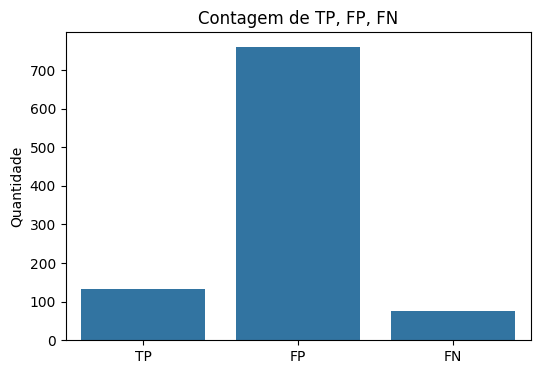

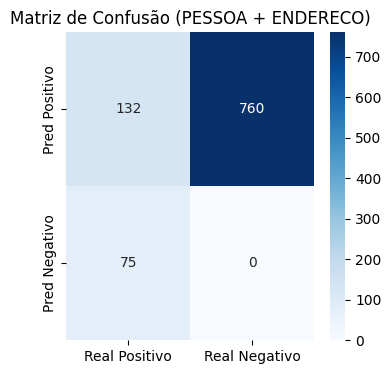

In [12]:
calcular_metricas('./resultado_final(person_location)-20.json', anotacoes)

QUALITATIVA

In [17]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

def analise_qualitativa(pred_path, anotacoes, output_path="resultado_qualitativa.txt", margem_erro=30):
    with open(pred_path, 'r', encoding='utf-8') as f:
        predicoes = json.load(f)

    chaves_comuns = set(predicoes.keys()) & set(anotacoes.keys())

    resumo = {
        "IGUAL": 0,
        "CAIXA": 0,
        "PREV_MENOR": 0,
        "PREV_MAIOR": 0,
        "FALSO_POSITIVO": 0,
        "FALSO_NEGATIVO": 0
    }

    with open(output_path, "w", encoding="utf-8") as arquivo:
        arquivo.write(f"Comparando {len(chaves_comuns)} documentos em comum.\n\n")

        for doc_id in chaves_comuns:
            verdadeiras = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in anotacoes[doc_id]
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]
            preditas = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in predicoes.get(doc_id, [])
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]

            matched_preds = set()
            matched_verdadeiras = set()

            for i, (v_ini, v_fim, v_tipo, v_texto) in enumerate(verdadeiras):
                matched = False
                for j, (p_ini, p_fim, p_tipo, p_texto) in enumerate(preditas):
                    if j in matched_preds:
                        continue
                    if (
                        v_tipo == p_tipo and
                        v_ini < p_fim and p_ini < v_fim and
                        abs(v_ini - p_ini) <= margem_erro and
                        abs(v_fim - p_fim) <= margem_erro
                    ):
                        matched_preds.add(j)
                        matched_verdadeiras.add(i)
                        matched = True

                        # Classificação qualitativa
                        if (v_ini, v_fim) == (p_ini, p_fim):
                            if v_texto == p_texto:
                                resumo["IGUAL"] += 1
                            elif v_texto.lower() == p_texto.lower():
                                resumo["CAIXA"] += 1
                            elif v_texto.lower() in p_texto.lower():
                                resumo["PREV_MAIOR"] += 1
                            elif p_texto.lower() in v_texto.lower():
                                resumo["PREV_MENOR"] += 1
                            else:
                                resumo["PREV_MAIOR"] += 1  # fallback
                        else:
                            if v_texto.lower() in p_texto.lower():
                                resumo["PREV_MAIOR"] += 1
                            elif p_texto.lower() in v_texto.lower():
                                resumo["PREV_MENOR"] += 1
                            else:
                                resumo["PREV_MAIOR"] += 1  # fallback

                        break

                if not matched:
                    resumo["FALSO_NEGATIVO"] += 1
                    arquivo.write(f"\nDocumento: {doc_id}\n")
                    arquivo.write(f"  anotacao: ({v_ini}, {v_fim}, {v_tipo}, '{v_texto}')\n")
                    arquivo.write(f"  pred:     ---\n")

            for j, (p_ini, p_fim, p_tipo, p_texto) in enumerate(preditas):
                if j not in matched_preds:
                    resumo["FALSO_POSITIVO"] += 1
                    arquivo.write(f"\nDocumento: {doc_id}\n")
                    arquivo.write(f"  anotacao: ---\n")
                    arquivo.write(f"  pred:     ({p_ini}, {p_fim}, {p_tipo}, '{p_texto}')\n")

        # Escreve resumo final
        arquivo.write("\n===== RESUMO QUALITATIVO =====\n")
        for k, v in resumo.items():
            arquivo.write(f"- {k}: {v}\n")

    # Exibe no console
    print("\n===== RESUMO QUALITATIVO =====")
    legendas = {
        "IGUAL": "Início, fim e texto coincidem exatamente (ignora caixa)",
        "CAIXA": "Início e fim iguais, texto igual ignorando maiúsculas/minúsculas",
        "PREV_MENOR": "Texto da predição é menor, contido na anotação",
        "PREV_MAIOR": "Texto da predição é maior, contém a anotação",
        "FALSO_POSITIVO": "Predição sem correspondente na anotação (falso positivo)",
        "FALSO_NEGATIVO": "Anotação sem correspondente na predição (falso negativo)"
    }

    for k, v in resumo.items():
        descricao = legendas.get(k, "")
        print(f"- {k}: {v}  →  {descricao}")

    # Gráfico
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(resumo.keys()), y=list(resumo.values()))
    plt.title("Análise Qualitativa das Entidades")
    plt.ylabel("Contagem")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



===== RESUMO QUALITATIVO =====
- IGUAL: 0  →  Início, fim e texto coincidem exatamente (ignora caixa)
- CAIXA: 104  →  Início e fim iguais, texto igual ignorando maiúsculas/minúsculas
- PREV_MENOR: 11  →  Texto da predição é menor, contido na anotação
- PREV_MAIOR: 17  →  Texto da predição é maior, contém a anotação
- FALSO_POSITIVO: 760  →  Predição sem correspondente na anotação (falso positivo)
- FALSO_NEGATIVO: 75  →  Anotação sem correspondente na predição (falso negativo)


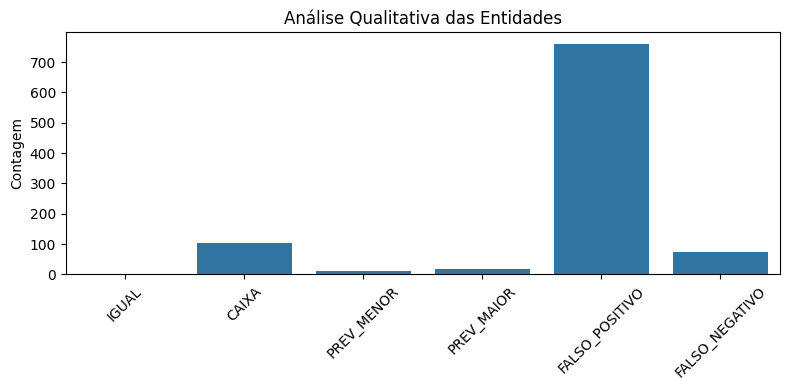

In [18]:
analise_qualitativa('./resultado_final(person_location)-20.json', anotacoes)